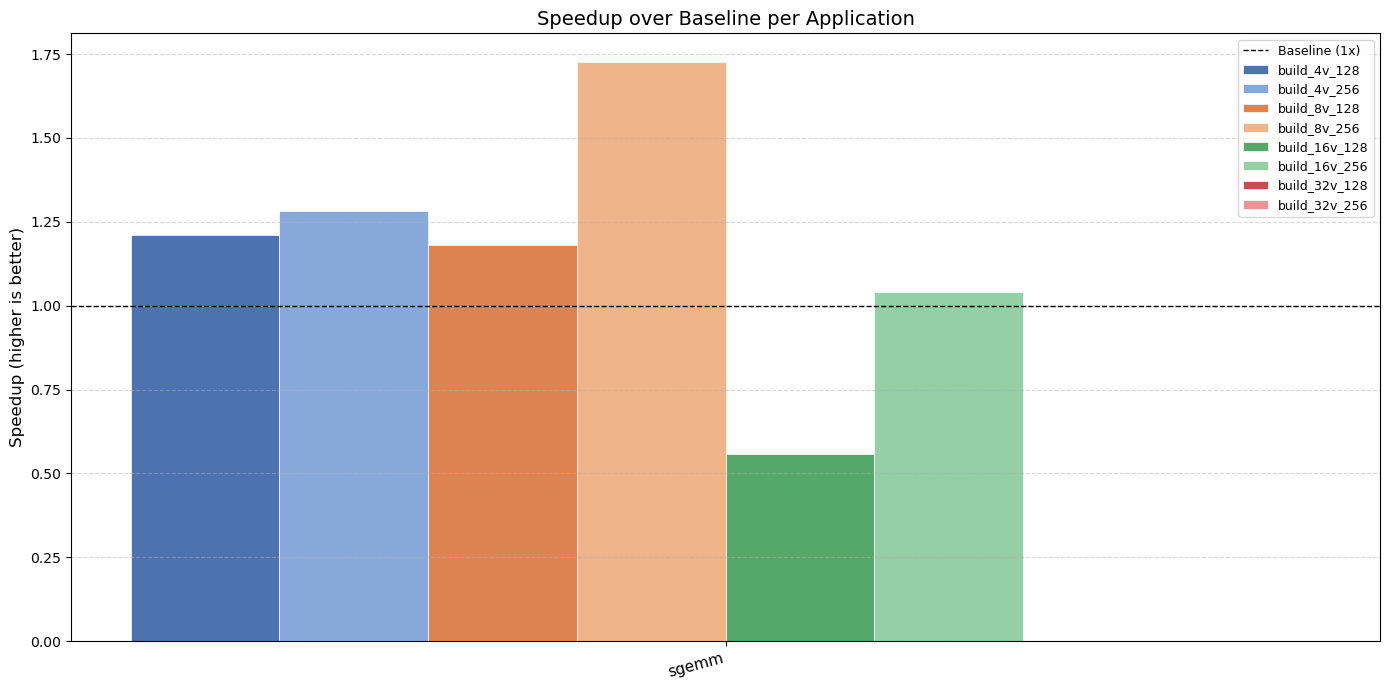

In [3]:
import os
import matplotlib.pyplot as plt
import numpy as np

BASE_DIR = "."

# Baseline directories and their variants
THREAD_COUNTS = [4, 8, 16, 32]
VARIANTS = ["v_128", "v_256"]

def read_cycles(path):
    cycles = {}
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            app, cyc = line.split(",")
            cycles[app.strip()] = int(cyc.strip())
    return cycles

# Load all data
baselines = {}
optimized = {}

for t in THREAD_COUNTS:
    base_path = os.path.join(BASE_DIR, f"build_{t}", "cycles.txt")
    if os.path.exists(base_path):
        baselines[t] = read_cycles(base_path)

    for v in VARIANTS:
        opt_path = os.path.join(BASE_DIR, f"build_{t}{v}", "cycles.txt")
        if os.path.exists(opt_path):
            optimized[(t, v)] = read_cycles(opt_path)

# Get all apps from the first available baseline
all_apps = []
for t in THREAD_COUNTS:
    if t in baselines:
        all_apps = list(baselines[t].keys())
        break

# Compute speedups: speedup = baseline_cycles / optimized_cycles
# speedup > 1 means faster
speedups = {}  # (t, v) -> {app -> speedup}
for (t, v), opt_data in optimized.items():
    if t not in baselines:
        continue
    base_data = baselines[t]
    speedups[(t, v)] = {}
    for app in all_apps:
        if app in base_data and app in opt_data and opt_data[app] > 0:
            speedups[(t, v)][app] = base_data[app] / opt_data[app]

# Plot
n_apps = len(all_apps)
n_groups = len(THREAD_COUNTS)
n_bars_per_group = len(VARIANTS)  # 2 bars per thread count
total_bars_per_app = n_groups * n_bars_per_group

x = np.arange(n_apps)
bar_width = 0.8 / total_bars_per_app

colors = {
    (4,  "v_128"): "#4C72B0",
    (4,  "v_256"): "#87A9D9",
    (8,  "v_128"): "#DD8452",
    (8,  "v_256"): "#F0B48A",
    (16, "v_128"): "#55A868",
    (16, "v_256"): "#95CFA5",
    (32, "v_128"): "#C44E52",
    (32, "v_256"): "#E89598",
}

fig, ax = plt.subplots(figsize=(max(14, n_apps * 1.8), 7))

bar_idx = 0
for t in THREAD_COUNTS:
    for v in VARIANTS:
        key = (t, v)
        if key not in speedups:
            bar_idx += 1
            continue
        values = [speedups[key].get(app, 0) for app in all_apps]
        offset = (bar_idx - total_bars_per_app / 2 + 0.5) * bar_width
        bars = ax.bar(x + offset, values, bar_width, label=f"build_{t}{v}",
                      color=colors.get(key, None), edgecolor="white", linewidth=0.5)
        bar_idx += 1

ax.axhline(1.0, color="black", linestyle="--", linewidth=1, label="Baseline (1x)")
ax.set_xticks(x)
ax.set_xticklabels(all_apps, rotation=15, ha="right", fontsize=11)
ax.set_ylabel("Speedup (higher is better)", fontsize=12)
ax.set_title("Speedup over Baseline per Application", fontsize=14)
ax.legend(loc="upper right", fontsize=9)
ax.set_ylim(bottom=0)
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
#plt.savefig("speedup.png", dpi=150)
#print("Saved speedup.png")

Saved speedup.png


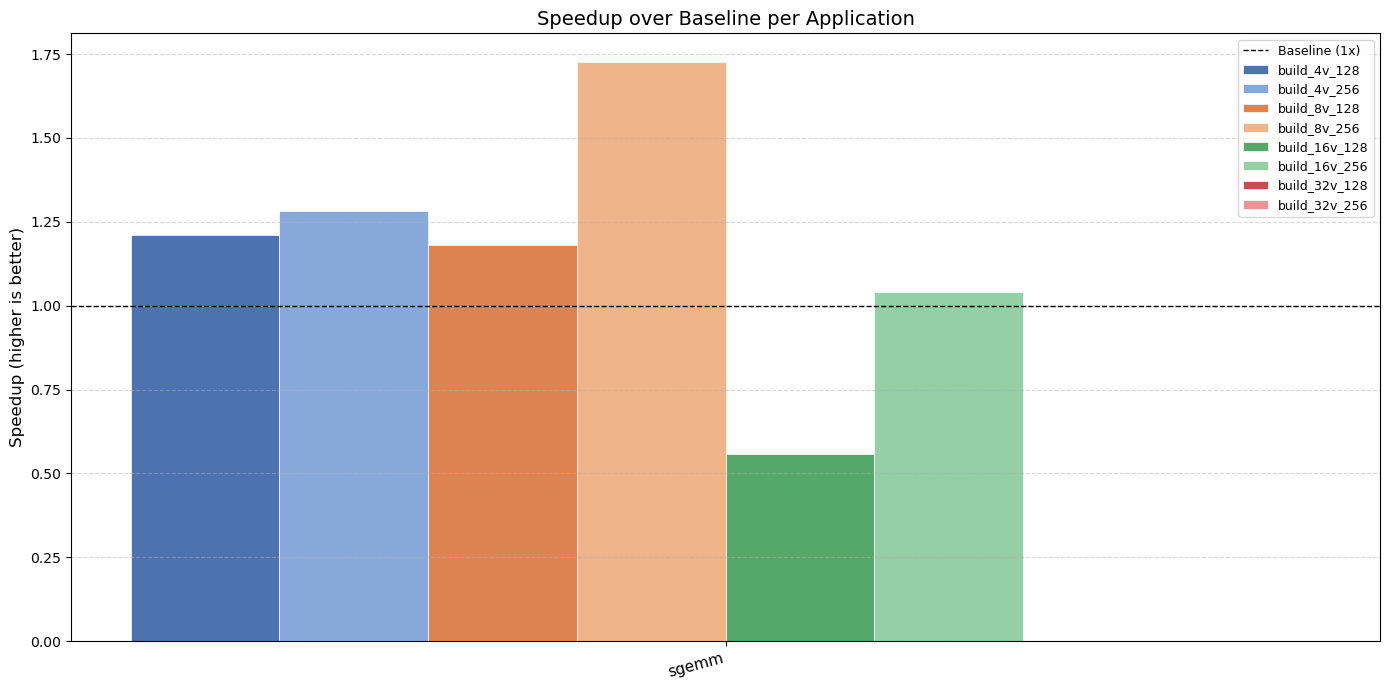

In [4]:
import os
import matplotlib.pyplot as plt
import numpy as np

BASE_DIR = "."

# Baseline directories and their variants
THREAD_COUNTS = [4, 8, 16, 32]
VARIANTS = ["v_128", "v_256"]

def read_cycles(path):
    cycles = {}
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            app, cyc = line.split(",")
            cycles[app.strip()] = int(cyc.strip())
    return cycles

# Load all data
baselines = {}
optimized = {}

for t in THREAD_COUNTS:
    base_path = os.path.join(BASE_DIR, f"build_{t}", "cycles.txt")
    if os.path.exists(base_path):
        baselines[t] = read_cycles(base_path)

    for v in VARIANTS:
        opt_path = os.path.join(BASE_DIR, f"build_{t}{v}", "cycles.txt")
        if os.path.exists(opt_path):
            optimized[(t, v)] = read_cycles(opt_path)

# Get all apps from the first available baseline
all_apps = []
for t in THREAD_COUNTS:
    if t in baselines:
        all_apps = list(baselines[t].keys())
        break

all_apps = [app for app in all_apps if app != "softmax"]

# Compute speedups: speedup = baseline_cycles / optimized_cycles
# speedup > 1 means faster
speedups = {}  # (t, v) -> {app -> speedup}
for (t, v), opt_data in optimized.items():
    if t not in baselines:
        continue
    base_data = baselines[t]
    speedups[(t, v)] = {}
    for app in all_apps:
        if app in base_data and app in opt_data and opt_data[app] > 0:
            speedups[(t, v)][app] = base_data[app] / opt_data[app]

# Plot
n_apps = len(all_apps)
n_groups = len(THREAD_COUNTS)
n_bars_per_group = len(VARIANTS)  # 2 bars per thread count
total_bars_per_app = n_groups * n_bars_per_group

x = np.arange(n_apps)
bar_width = 0.8 / total_bars_per_app

colors = {
    (4,  "v_128"): "#4C72B0",
    (4,  "v_256"): "#87A9D9",
    (8,  "v_128"): "#DD8452",
    (8,  "v_256"): "#F0B48A",
    (16, "v_128"): "#55A868",
    (16, "v_256"): "#95CFA5",
    (32, "v_128"): "#C44E52",
    (32, "v_256"): "#E89598",
}

fig, ax = plt.subplots(figsize=(max(14, n_apps * 1.8), 7))

bar_idx = 0
for t in THREAD_COUNTS:
    for v in VARIANTS:
        key = (t, v)
        if key not in speedups:
            bar_idx += 1
            continue
        values = [speedups[key].get(app, 0) for app in all_apps]
        offset = (bar_idx - total_bars_per_app / 2 + 0.5) * bar_width
        bars = ax.bar(x + offset, values, bar_width, label=f"build_{t}{v}",
                      color=colors.get(key, None), edgecolor="white", linewidth=0.5)
        bar_idx += 1

ax.axhline(1.0, color="black", linestyle="--", linewidth=1, label="Baseline (1x)")
ax.set_xticks(x)
ax.set_xticklabels(all_apps, rotation=15, ha="right", fontsize=11)
ax.set_ylabel("Speedup (higher is better)", fontsize=12)
ax.set_title("Speedup over Baseline per Application", fontsize=14)
ax.legend(loc="upper right", fontsize=9)
ax.set_ylim(bottom=0)
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("speedup.png", dpi=150)
print("Saved speedup.png")

Saved speedup.png


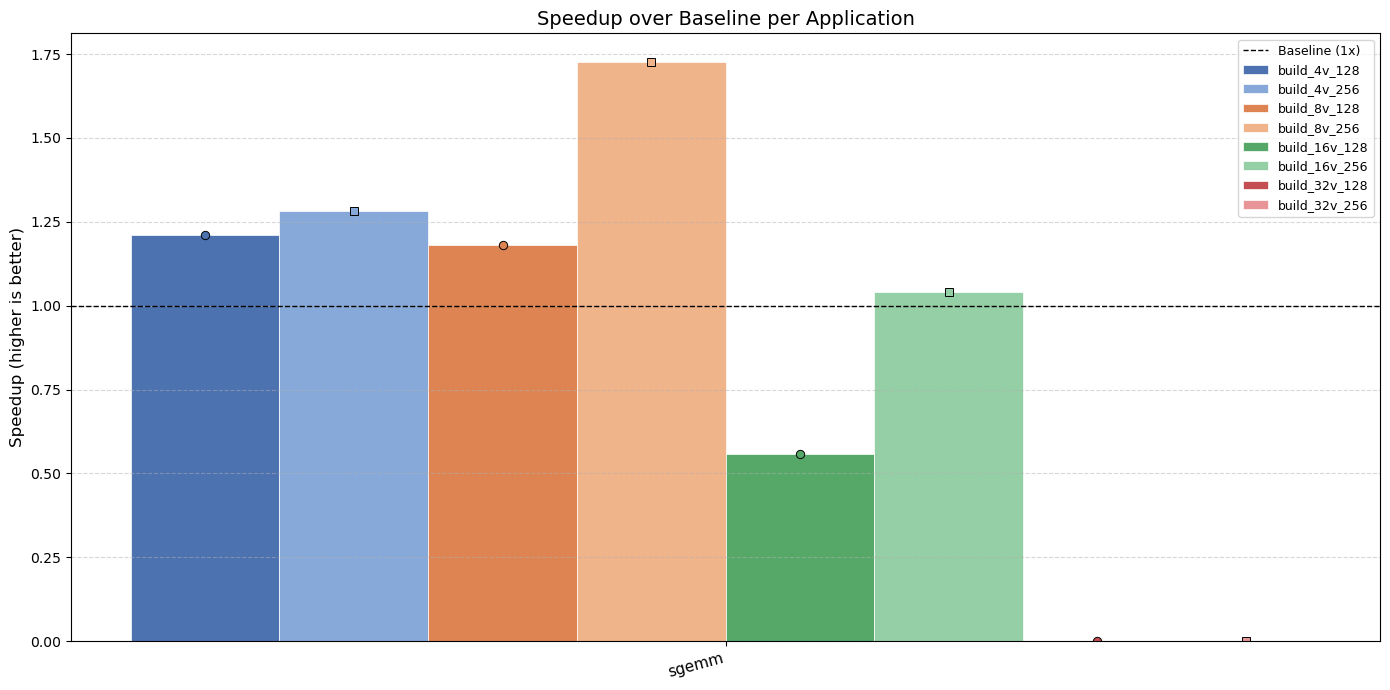

In [5]:
import os
import matplotlib.pyplot as plt
import numpy as np

BASE_DIR = "."

# Baseline directories and their variants
THREAD_COUNTS = [4, 8, 16, 32]
VARIANTS = ["v_128", "v_256"]

def read_cycles(path):
    cycles = {}
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            app, cyc = line.split(",")
            cycles[app.strip()] = int(cyc.strip())
    return cycles

# Load all data
baselines = {}
optimized = {}

for t in THREAD_COUNTS:
    base_path = os.path.join(BASE_DIR, f"build_{t}", "cycles.txt")
    if os.path.exists(base_path):
        baselines[t] = read_cycles(base_path)

    for v in VARIANTS:
        opt_path = os.path.join(BASE_DIR, f"build_{t}{v}", "cycles.txt")
        if os.path.exists(opt_path):
            optimized[(t, v)] = read_cycles(opt_path)

# Get all apps from the first available baseline
all_apps = []
for t in THREAD_COUNTS:
    if t in baselines:
        all_apps = list(baselines[t].keys())
        break

all_apps = [app for app in all_apps if app != "softmax"]

ORDER = ["sgemm", "sgemv", "jacobi", "vecadd", "pathfinder", "dropout", "dotproduct", "bfs"]
all_apps = [app for app in ORDER if app in all_apps]

# Compute speedups: speedup = baseline_cycles / optimized_cycles
# speedup > 1 means faster
speedups = {}  # (t, v) -> {app -> speedup}
for (t, v), opt_data in optimized.items():
    if t not in baselines:
        continue
    base_data = baselines[t]
    speedups[(t, v)] = {}
    for app in all_apps:
        if app in base_data and app in opt_data and opt_data[app] > 0:
            speedups[(t, v)][app] = base_data[app] / opt_data[app]

# Plot
n_apps = len(all_apps)
n_groups = len(THREAD_COUNTS)
n_bars_per_group = len(VARIANTS)  # 2 bars per thread count
total_bars_per_app = n_groups * n_bars_per_group

x = np.arange(n_apps)
bar_width = 0.8 / total_bars_per_app

colors = {
    (4,  "v_128"): "#4C72B0",
    (4,  "v_256"): "#87A9D9",
    (8,  "v_128"): "#DD8452",
    (8,  "v_256"): "#F0B48A",
    (16, "v_128"): "#55A868",
    (16, "v_256"): "#95CFA5",
    (32, "v_128"): "#C44E52",
    (32, "v_256"): "#E89598",
}

fig, ax = plt.subplots(figsize=(max(14, n_apps * 1.8), 7))

bar_idx = 0
for t in THREAD_COUNTS:
    for v in VARIANTS:
        key = (t, v)
        if key not in speedups:
            bar_idx += 1
            continue
        values = [speedups[key].get(app, 0) for app in all_apps]
        offset = (bar_idx - total_bars_per_app / 2 + 0.5) * bar_width
        bars = ax.bar(x + offset, values, bar_width, label=f"build_{t}{v}",
                      color=colors.get(key, None), edgecolor="white", linewidth=0.5)
        marker = "o" if v == "v_128" else "s"
        ax.plot(x + offset, values, marker=marker, linestyle="none",
                color=colors.get(key, None), markeredgecolor="black",
                markeredgewidth=0.7, markersize=6)
        bar_idx += 1

ax.axhline(1.0, color="black", linestyle="--", linewidth=1, label="Baseline (1x)")
ax.set_xticks(x)
ax.set_xticklabels(all_apps, rotation=15, ha="right", fontsize=11)
ax.set_ylabel("Speedup (higher is better)", fontsize=12)
ax.set_title("Speedup over Baseline per Application", fontsize=14)
ax.legend(loc="upper right", fontsize=9)
ax.set_ylim(bottom=0)
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("speedup.png", dpi=150)
print("Saved speedup.png")

Saved speedup.pdf


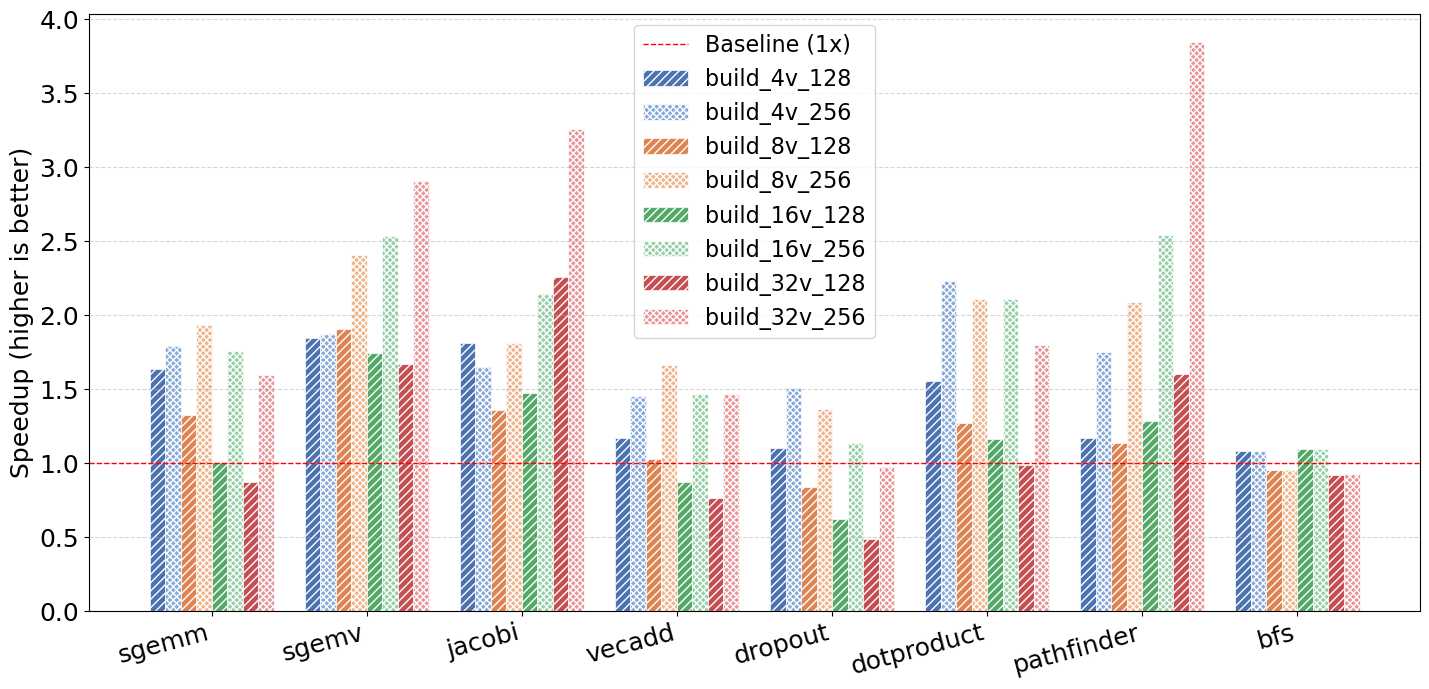

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# ── Baselines ─────────────────────────────────────────────────────────────────
baselines = {
    4: {
        "vecadd": 5157995, "pathfinder": 30961,  "dropout": 5861461,
        "dotproduct": 10641015, "bfs": 2421, "sgemm": 6845781,
        "sgemv": 12283677, "jacobi": 518530,
    },
    8: {
        "vecadd": 4695881, "pathfinder": 33754,  "dropout": 4795086,
        "dotproduct": 7469432, "bfs": 2794, "sgemm": 4005264,
        "sgemv": 10150963, "jacobi": 343399,
    },
    16: {
        "vecadd": 4294872, "pathfinder": 46587,  "dropout": 4321217,
        "dotproduct": 5943199, "bfs": 5323, "sgemm": 23153300,
        "sgemv": 8082927, "jacobi": 333625,
    },
    32: {
        "vecadd": 4159353, "pathfinder": 76453,  "dropout": 4178511,
        "dotproduct": 5189018, "bfs": 7605, "sgemm": 18725696,
        "sgemv": 7082927, "jacobi": 471316,
    },
}

# ── Optimized ──────────────────────────────────────────────────────────────────
optimized = {
    (4, "v_128"): {
        "vecadd": 4424639, "pathfinder": 26592,  "dropout": 5334110,
        "dotproduct": 6839384, "bfs": 2239, "sgemm": 4182703,
        "sgemv": 6675234, "jacobi": 286809,
    },
    (4, "v_256"): {
        "vecadd": 3553035, "pathfinder": 17725,  "dropout": 3901429,
        "dotproduct": 4773914, "bfs": 2239, "sgemm": 3824680,
        "sgemv": 6578930, "jacobi": 314655,
    },
    (8, "v_128"): {
        "vecadd": 4579915, "pathfinder": 29763,  "dropout": 5759472,
        "dotproduct": 5900721, "bfs": 2949, "sgemm": 3031590,
        "sgemv": 5336555, "jacobi": 252836,
    },
    (8, "v_256"): {
        "vecadd": 2827675, "pathfinder": 16195,  "dropout": 3520183,
        "dotproduct": 3548066, "bfs": 2949, "sgemm": 2074144,
        "sgemv": 4221824, "jacobi": 189621,
    },
    (16, "v_128"): {
        "vecadd": 4943941, "pathfinder": 36407,  "dropout": 7003930,
        "dotproduct": 5130212, "bfs": 4883, "sgemm": 23051660,
        "sgemv": 4645175, "jacobi": 227109,
    },
    (16, "v_256"): {
        "vecadd": 2931388, "pathfinder": 18367,  "dropout": 3809840,
        "dotproduct": 2817807, "bfs": 4865, "sgemm": 13169052,
        "sgemv": 3189602, "jacobi": 155604,
    },
    (32, "v_128"): {
        "vecadd": 5449790, "pathfinder": 47843,  "dropout": 8645877,
        "dotproduct": 5269495, "bfs": 8299, "sgemm": 21600529,
        "sgemv": 4251690, "jacobi": 209121,
    },
    (32, "v_256"): {
        "vecadd": 2840983, "pathfinder": 19884,  "dropout": 4316477,
        "dotproduct": 2885042, "bfs": 8263, "sgemm": 11732992,
        "sgemv": 2439062, "jacobi": 144776,
    },
}

# ── App order (no softmax) ─────────────────────────────────────────────────────
ORDER = ["sgemm", "sgemv", "jacobi", "vecadd", "dropout", "dotproduct", "pathfinder", "bfs"]
all_apps = ORDER

THREAD_COUNTS = [4, 8, 16, 32]
VARIANTS = ["v_128", "v_256"]

# ── Compute speedups ───────────────────────────────────────────────────────────
speedups = {}
for (t, v), opt_data in optimized.items():
    speedups[(t, v)] = {}
    for app in all_apps:
        base = baselines[t].get(app, 0)
        opt  = opt_data.get(app, 0)
        if base > 0 and opt > 0:
            speedups[(t, v)][app] = base / opt

# ── Plot ───────────────────────────────────────────────────────────────────────
n_apps = len(all_apps)
total_bars_per_app = len(THREAD_COUNTS) * len(VARIANTS)

x = np.arange(n_apps)
bar_width = 0.8 / total_bars_per_app

colors = {
    (4,  "v_128"): "#4C72B0",
    (4,  "v_256"): "#87A9D9",
    (8,  "v_128"): "#DD8452",
    (8,  "v_256"): "#F0B48A",
    (16, "v_128"): "#55A868",
    (16, "v_256"): "#95CFA5",
    (32, "v_128"): "#C44E52",
    (32, "v_256"): "#E89598",
}

fig, ax = plt.subplots(figsize=(max(14, n_apps * 1.8), 7))

bar_idx = 0
for t in THREAD_COUNTS:
    for v in VARIANTS:
        key = (t, v)
        values = [speedups[key].get(app, 0) for app in all_apps]
        offset = (bar_idx - total_bars_per_app / 2 + 0.5) * bar_width
        hatch = "////" if v == "v_128" else "xxxxx"
        ax.bar(x + offset, values, bar_width, label=f"build_{t}{v}",
               color=colors[key], edgecolor="white", linewidth=0.5,
               hatch=hatch)
        bar_idx += 1

ax.axhline(1.0, color="red", linestyle="--", linewidth=1, label="Baseline (1x)")
ax.set_xticks(x)
ax.set_xticklabels(all_apps, rotation=15, ha="right", fontsize=18)
ax.set_ylabel("Speedup (higher is better)", fontsize=18)
ax.set_ylim(bottom=0)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.set_xticklabels(all_apps, rotation=15, ha="right", fontsize=18)
ax.set_ylabel("Speedup (higher is better)", fontsize=18)
ax.legend(loc="upper center", ncol=1, fontsize=16)
ax.tick_params(axis='y', labelsize=18)


plt.tight_layout()
plt.savefig("speedup.pdf", format="pdf", bbox_inches="tight")
print("Saved speedup.pdf")

Saved speedup.pdf


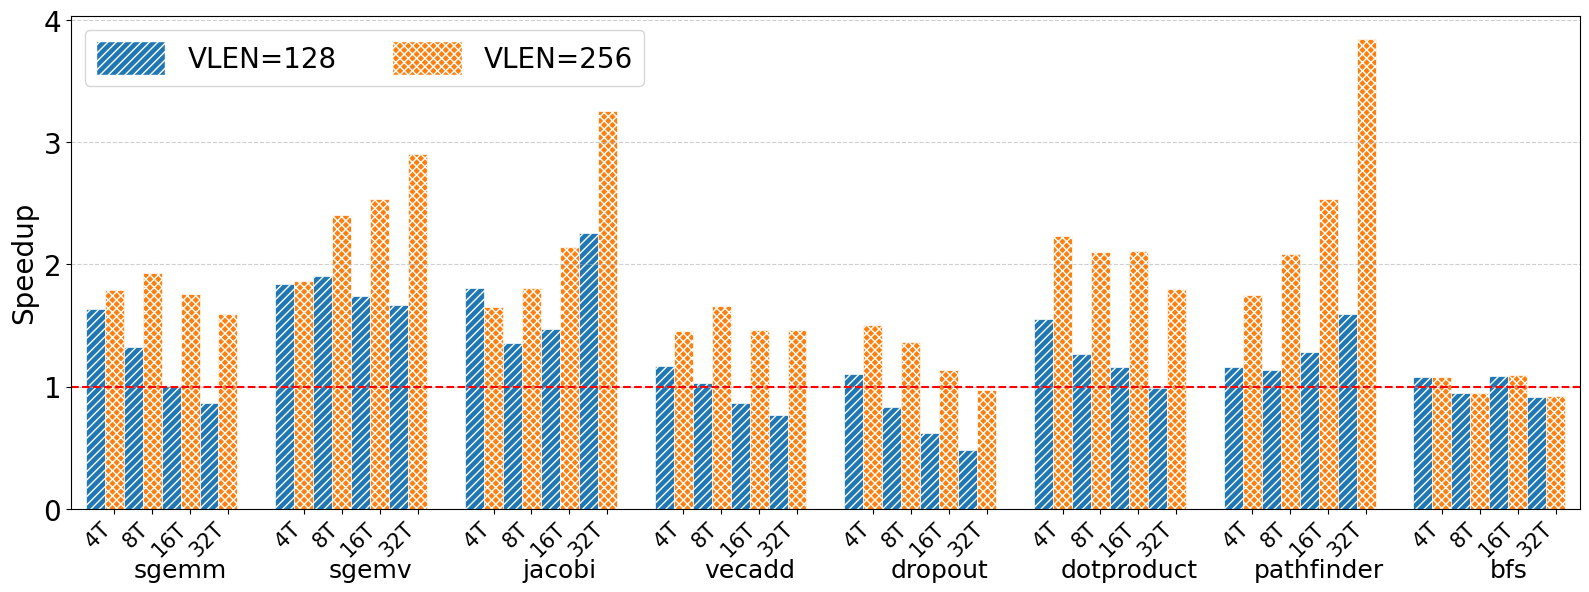

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# ── Baselines ─────────────────────────────────────────────────────────────────
baselines = {
    4: {
        "vecadd": 5157995, "pathfinder": 30961,  "dropout": 5861461,
        "dotproduct": 10641015, "bfs": 2421, "sgemm": 6845781,
        "sgemv": 12283677, "jacobi": 518530,
    },
    8: {
        "vecadd": 4695881, "pathfinder": 33754,  "dropout": 4795086,
        "dotproduct": 7469432, "bfs": 2794, "sgemm": 4005264,
        "sgemv": 10150963, "jacobi": 343399,
    },
    16: {
        "vecadd": 4294872, "pathfinder": 46587,  "dropout": 4321217,
        "dotproduct": 5943199, "bfs": 5323, "sgemm": 23153300,
        "sgemv": 8082927, "jacobi": 333625,
    },
    32: {
        "vecadd": 4159353, "pathfinder": 76453,  "dropout": 4178511,
        "dotproduct": 5189018, "bfs": 7605, "sgemm": 18725696,
        "sgemv": 7082927, "jacobi": 471316,
    },
}

# ── Optimized ──────────────────────────────────────────────────────────────────
optimized = {
    (4, "v_128"): {
        "vecadd": 4424639, "pathfinder": 26592,  "dropout": 5334110,
        "dotproduct": 6839384, "bfs": 2239, "sgemm": 4182703,
        "sgemv": 6675234, "jacobi": 286809,
    },
    (4, "v_256"): {
        "vecadd": 3553035, "pathfinder": 17725,  "dropout": 3901429,
        "dotproduct": 4773914, "bfs": 2239, "sgemm": 3824680,
        "sgemv": 6578930, "jacobi": 314655,
    },
    (8, "v_128"): {
        "vecadd": 4579915, "pathfinder": 29763,  "dropout": 5759472,
        "dotproduct": 5900721, "bfs": 2949, "sgemm": 3031590,
        "sgemv": 5336555, "jacobi": 252836,
    },
    (8, "v_256"): {
        "vecadd": 2827675, "pathfinder": 16195,  "dropout": 3520183,
        "dotproduct": 3548066, "bfs": 2949, "sgemm": 2074144,
        "sgemv": 4221824, "jacobi": 189621,
    },
    (16, "v_128"): {
        "vecadd": 4943941, "pathfinder": 36407,  "dropout": 7003930,
        "dotproduct": 5130212, "bfs": 4883, "sgemm": 23051660,
        "sgemv": 4645175, "jacobi": 227109,
    },
    (16, "v_256"): {
        "vecadd": 2931388, "pathfinder": 18367,  "dropout": 3809840,
        "dotproduct": 2817807, "bfs": 4865, "sgemm": 13169052,
        "sgemv": 3189602, "jacobi": 155604,
    },
    (32, "v_128"): {
        "vecadd": 5449790, "pathfinder": 47843,  "dropout": 8645877,
        "dotproduct": 5269495, "bfs": 8299, "sgemm": 21600529,
        "sgemv": 4251690, "jacobi": 209121,
    },
    (32, "v_256"): {
        "vecadd": 2840983, "pathfinder": 19884,  "dropout": 4316477,
        "dotproduct": 2885042, "bfs": 8263, "sgemm": 11732992,
        "sgemv": 2439062, "jacobi": 144776,
    },
}

# ── App order ─────────────────────────────────────────────────────────────────
ORDER = ["sgemm", "sgemv", "jacobi", "vecadd", "dropout", "dotproduct", "pathfinder", "bfs"]
all_apps = ORDER
THREAD_COUNTS = [4, 8, 16, 32]
VARIANTS = ["v_128", "v_256"]

# ── Compute speedups ───────────────────────────────────────────────────────────
speedups = {}
for (t, v), opt_data in optimized.items():
    speedups[(t, v)] = {}
    for app in all_apps:
        base = baselines[t].get(app, 0)
        opt  = opt_data.get(app, 0)
        if base > 0 and opt > 0:
            speedups[(t, v)][app] = base / opt

# ── Build positions (like reference plot) ─────────────────────────────────────
bar_width = 0.05
inner_gap = bar_width
outer_gap = 0.1

variant_colors = {"v_128": "tab:blue", "v_256": "tab:orange"}
variant_hatch  = {"v_128": "////",    "v_256": "xxxx"}

positions       = []
values_list     = []
labels_list     = []   # variant label for color/hatch
tick_positions  = []
tick_labels     = []
bench_positions = []
bench_labels    = []

current_pos = 0

for app in all_apps:
    group_start  = current_pos
    n_variants   = len(VARIANTS)
    offsets      = np.linspace(-(n_variants - 1) / 2,
                                (n_variants - 1) / 2,
                                n_variants) * inner_gap

    for t in THREAD_COUNTS:
        for offset, v in zip(offsets, VARIANTS):
            positions.append(current_pos + offset)
            values_list.append(speedups.get((t, v), {}).get(app, 0))
            labels_list.append(v)
        current_pos += n_variants * inner_gap

    # Tick per thread count (centre of its 2 bars)
    for i, t in enumerate(THREAD_COUNTS):
        tick_positions.append(group_start + i * n_variants * inner_gap
                              + (n_variants - 1) / 2 * inner_gap)
        tick_labels.append(f"{t}T")

    # App label centred under the whole group
    group_width = len(THREAD_COUNTS) * n_variants * inner_gap
    bench_positions.append(group_start + group_width / 2)
    bench_labels.append(app)

    current_pos = group_start + group_width + outer_gap

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))


"""
for pos, value, v in zip(positions, values_list, labels_list):
    ax.bar(pos, value, width=bar_width,
           color=variant_colors[v], hatch=variant_hatch[v],
           edgecolor="black", linewidth=0.5)
"""

for pos, value, v in zip(positions, values_list, labels_list):
    ax.bar(pos, value, width=bar_width,
           color=variant_colors[v], hatch=variant_hatch[v],
           edgecolor="white", linewidth=0.5)


# Thread-count ticks
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=15)

# App name labels below
for pos, label in zip(bench_positions, bench_labels):
    ax.text(pos, -0.1, label, ha='center', va='top',
            transform=ax.get_xaxis_transform(), fontsize=18)

ax.axhline(1.0, color="red", linestyle="--", linewidth=1.5, label="Baseline (1x)")
ax.set_ylabel("Speedup", fontsize=20)
ax.tick_params(axis='y', labelsize=20)
ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.set_ylim(bottom=0)
ax.margins(x=0.01)

# ── Legend: only 2 entries ─────────────────────────────────────────────────────
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor="tab:blue", hatch=variant_hatch["v_128"],
          edgecolor="white", label="VLEN=128"),
    Patch(facecolor="tab:orange", hatch=variant_hatch["v_256"],
          edgecolor="white", label="VLEN=256"),
]
ax.legend(handles=legend_handles, loc="upper left", ncol=2,
          fontsize=20, handlelength=2.5, handleheight=1.5)

plt.tight_layout()
plt.savefig("speedup.pdf", format="pdf", bbox_inches="tight")
print("Saved speedup.pdf")

Saved configs.png


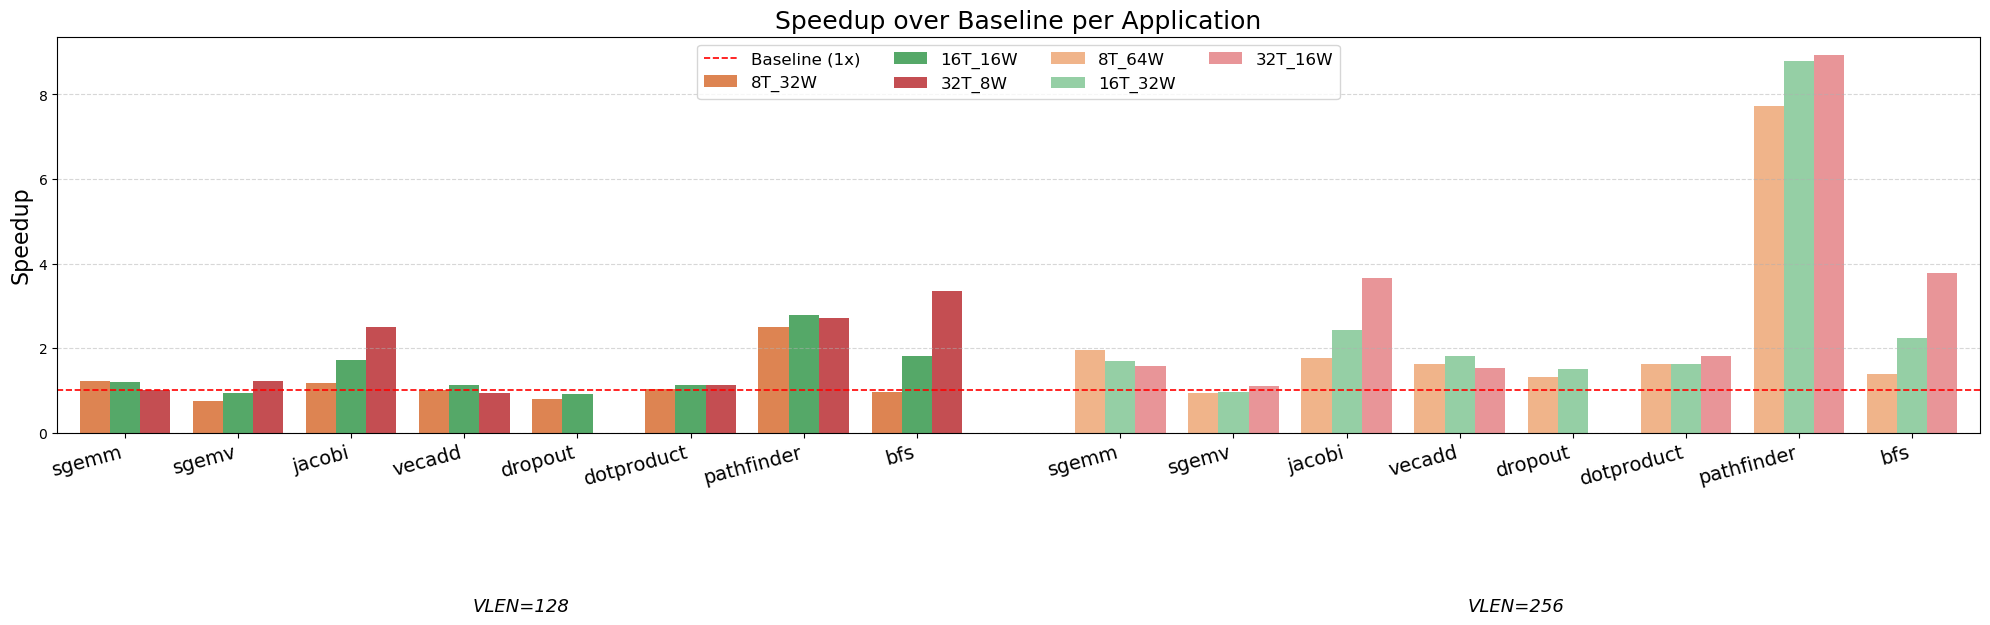

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# ── Baselines ──────────────────────────────────────────────────────────────────
baseline_128 = {
    "sgemm": 3031590, "sgemv": 5336555, "jacobi": 252836,
    "vecadd": 4579915, "dropout": 5759472, "dotproduct": 5900721,
    "pathfinder": 29763, "bfs": 2949,
}
baseline_256 = {
    "sgemm": 2074144, "sgemv": 4221824, "jacobi": 189621,
    "vecadd": 2827675, "dropout": 3520183, "dotproduct": 3548066,
    "pathfinder": 16195, "bfs": 2949,
}

# ── Config Set 1 (vs 8T_8W_128 baseline) ──────────────────────────────────────
set1_configs = ["8T_32W", "16T_16W", "32T_8W"]
set1_data = {
    "8T_32W": {
        "sgemm": 3687510, "sgemv": 3975407, "jacobi": 294823,
        "vecadd": 4579018, "dropout": 4657092, "dotproduct": 6172601,
        "pathfinder": 74328, "bfs": 2854,
    },
    "16T_16W": {
        "sgemm": 3626423, "sgemv": 5009223, "jacobi": 434467,
        "vecadd": 5130524, "dropout": 5238769, "dotproduct": 6687781,
        "pathfinder": 83036, "bfs": 5376,
    },
    "32T_8W": {
        "sgemm": 3029899, "sgemv": 6469309, "jacobi": 630382,
        "vecadd": 4263301, "dropout": None, "dotproduct": 6724143,
        "pathfinder": 80794, "bfs": 9883,
    },
}

# ── Config Set 2 (vs 8T_8W_256 baseline) ──────────────────────────────────────
set2_configs = ["8T_64W", "16T_32W", "32T_16W"]
set2_data = {
    "8T_64W": {
        "sgemm": 4043263, "sgemv": 4007550, "jacobi": 336733,
        "vecadd": 4585695, "dropout": 4667345, "dotproduct": 5792927,
        "pathfinder": 125009, "bfs": 4108,
    },
    "16T_32W": {
        "sgemm":3517598 , "sgemv": 4046681, "jacobi": 461183,
        "vecadd": 5127403, "dropout": 5278723, "dotproduct": 5776482,
        "pathfinder": 142236, "bfs": 6581,
    },
    "32T_16W": {
        "sgemm": 3285476, "sgemv": 4623618, "jacobi": 694003,
        "vecadd": 4299864, "dropout": None, "dotproduct": 6453021,
        "pathfinder": 144486, "bfs": 11131,
    },
}

# ── App order ──────────────────────────────────────────────────────────────────
ORDER = ["sgemm", "sgemv", "jacobi", "vecadd", "dropout", "dotproduct", "pathfinder", "bfs"]

# ── Compute speedups (None = missing, skip) ────────────────────────────────────
def compute_speedups(configs, data, baseline):
    result = {}
    for cfg in configs:
        result[cfg] = {}
        for app in ORDER:
            base = baseline.get(app)
            opt  = data[cfg].get(app)
            if base and opt:
                result[cfg][app] = opt / base
            else:
                result[cfg][app] = None
    return result

speedups1 = compute_speedups(set1_configs, set1_data, baseline_128)
speedups2 = compute_speedups(set2_configs, set2_data, baseline_256)

# ── Layout ─────────────────────────────────────────────────────────────────────
n_apps    = len(ORDER)
n_configs = 3
bar_width = 0.8 / n_configs
block_gap = 0.8

x1 = np.arange(n_apps, dtype=float)
x2 = x1 + n_apps + block_gap

set1_colors = ["#DD8452", "#55A868", "#C44E52"]
set2_colors = ["#F0B48A", "#95CFA5", "#E89598"]
hatches     = ["////", "xxxx", "----"]

fig, ax = plt.subplots(figsize=(20, 7))

for i, cfg in enumerate(set1_configs):
    offset = (i - n_configs / 2 + 0.5) * bar_width
    for j, app in enumerate(ORDER):
        val = speedups1[cfg].get(app)
        if val is not None:
            ax.bar(x1[j] + offset, val, bar_width,
                   label=cfg if j == 0 else None,
                   color=set1_colors[i], edgecolor="none", hatch=hatches[i])

for i, cfg in enumerate(set2_configs):
    offset = (i - n_configs / 2 + 0.5) * bar_width
    for j, app in enumerate(ORDER):
        val = speedups2[cfg].get(app)
        if val is not None:
            ax.bar(x2[j] + offset, val, bar_width,
                   label=cfg if j == 0 else None,
                   color=set2_colors[i], edgecolor="none", hatch=hatches[i])

ax.axhline(1.0, color="red", linestyle="--", linewidth=1.2, label="Baseline (1x)")

all_x = np.concatenate([x1, x2])
all_labels = ORDER + ORDER
ax.set_xticks(all_x)
ax.set_xticklabels(all_labels, rotation=15, ha="right", fontsize=14)
ax.set_xlim(x1[0] - 0.6, x2[-1] + 0.6)

ax.set_ylabel("Speedup", fontsize=16)
ax.set_title("Speedup over Baseline per Application", fontsize=18)
ax.legend(loc="upper center", fontsize=12, ncol=4, bbox_to_anchor=(0.5, 1.0))
ax.set_ylim(bottom=0)
ax.grid(axis="y", linestyle="--", alpha=0.5)

mid1 = (x1[0] + x1[-1]) / 2
mid2 = (x2[0] + x2[-1]) / 2
ax.text(mid1, -0.45, "VLEN=128", ha="center", fontsize=13,
        transform=ax.get_xaxis_transform(), fontstyle="italic")
ax.text(mid2, -0.45, "VLEN=256", ha="center", fontsize=13,
        transform=ax.get_xaxis_transform(), fontstyle="italic")

plt.tight_layout()
plt.savefig("configs.png", dpi=150)
print("Saved configs.png")